# L5: 2D Reactor Models

Many industrial reactors require 2D descriptions: a tubular reactor with radial temperature/concentration gradients, or a cylindrical catalyst pellet with internal diffusion. This notebook extends pymrm's 1D operators to 2D using Kronecker products, and introduces the cylindrical divergence operator.

## Governing equations

**2D Cartesian CDR** (cell centres at $(z_i, r_j)$):

$$\frac{\partial c}{\partial t} = D_z \frac{\partial^2 c}{\partial z^2} + D_r \frac{\partial^2 c}{\partial r^2} + R(c)$$

**2D cylindrical CDR** (with $\nu = 1$ for cylindrical, $\nu = 2$ for spherical):

$$\frac{\partial c}{\partial t} = D_z \frac{\partial^2 c}{\partial z^2} + \frac{D_r}{r^{\nu}} \frac{\partial}{\partial r}\left(r^{\nu}\frac{\partial c}{\partial r}\right) + R(c)$$

**Kronecker product assembly** for $N_z \times N_r$ grid:

$$\mathbf{L} = \mathbf{I}_{N_r} \otimes \mathbf{L}_z + \mathbf{L}_r \otimes \mathbf{I}_{N_z}$$

where $\mathbf{L}_z = \mathbf{D}_z\,\mathbf{G}_z$ and similarly for $r$.

## PyMRM building blocks

| Tool | Role |
|---|---|
| `construct_grad(N, dz, axis=0)` | 1D gradient in $z$ or $r$ |
| `construct_div(N, dz, nu=0)` | Divergence; `nu=1` for cylindrical |
| `scipy.sparse.kron(A, B)` | Kronecker product to assemble 2D operator |
| `scipy.sparse.eye(N)` | Identity of size $N$ |
| Array shape `(Nz, Nr, Nc)` | 2D multi-component concentration field |

## Example 1 — 2D Cartesian diffusion-reaction

Steady-state diffusion-reaction in a rectangular domain with Dirichlet BCs on all walls.

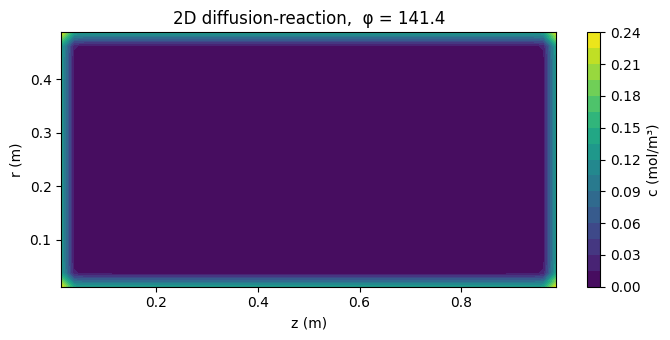

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# Grid
Lz, Lr = 1.0, 0.5
Nz, Nr = 40, 20
dz, dr = Lz/Nz, Lr/Nr
z = (np.arange(Nz) + 0.5) * dz
r = (np.arange(Nr) + 0.5) * dr
D, k = 1e-4, 2.0
c_wall = 1.0

# 1D operators (face coordinates for pymrm)
z_f = np.linspace(0, Lz, Nz + 1)
r_f = np.linspace(0, Lr, Nr + 1)

# Assemble 2D Laplacian via Kronecker
# Interior operator (without ghost cells): use finite-difference tridiagonal
def laplacian_1d(N, h, D_coeff, bc='dirichlet'):
    main = -2*D_coeff/h**2 * np.ones(N)
    off = D_coeff/h**2
    A = sp.diags([off*np.ones(N-1), main, off*np.ones(N-1)], [-1,0,1], format='csr')
    rhs_bc = np.zeros(N)
    if bc == 'dirichlet':
        A[0, 0] -= off; A[-1, -1] -= off  # ghost-cell correction
        rhs_bc[0] = -2*off*c_wall; rhs_bc[-1] = -2*off*c_wall
    return A, rhs_bc

Az, rz = laplacian_1d(Nz, dz, D)
Ar, rr = laplacian_1d(Nr, dr, D)
Ir = sp.eye(Nr, format='csr')
Iz = sp.eye(Nz, format='csr')

L2D = sp.kron(Ir, Az) + sp.kron(Ar, Iz)
# RHS: BC contributions
rhs_z = np.tile(rz, Nr)   # repeated for each r row
rhs_r = np.repeat(rr, Nz) # repeated for each z column
rhs2D = rhs_z + rhs_r

# Reaction term: -k*c on diagonal
A2D = L2D - k * sp.eye(Nz*Nr)
c_flat = spla.spsolve(A2D, rhs2D)
C = c_flat.reshape(Nr, Nz)

ZZ, RR = np.meshgrid(z, r)
plt.figure(figsize=(7, 3.5))
plt.contourf(ZZ, RR, C, 20, cmap='viridis')
plt.colorbar(label='c (mol/m³)')
plt.xlabel('z (m)'); plt.ylabel('r (m)')
phi = np.sqrt(k/D)
plt.title(f'2D diffusion-reaction,  φ = {phi:.1f}')
plt.tight_layout(); plt.show()


## Example 2 — Cylindrical catalyst pellet

Spherical catalyst pellet with $\nu = 2$: $\frac{d}{dr}\left(r^2 \frac{dc}{dr}\right) = \frac{r^2 k}{D} c$. Use `nu=2` in `construct_div`.

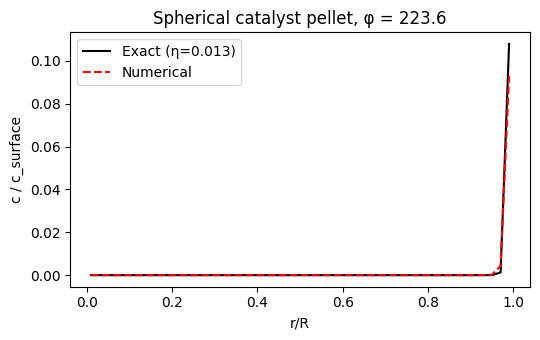

In [2]:
R_p = 1.0   # pellet radius [m] (normalised)
Np = 50
dr_p = R_p / Np
rp = (np.arange(Np) + 0.5) * dr_p
D_p, k_p = 1e-4, 5.0
phi_p = R_p * np.sqrt(k_p / D_p)

r_f_p = np.linspace(0, R_p, Np + 1)

# Build matrix: D_p * Dp @ diag(r²) @ Gp — use construct_div with nu=2
# Dirichlet at surface: c_ghost = 2*c_wall - c[-1]
c_surf = 1.0
off_p = D_p / dr_p**2
# Simplified: finite difference with cylindrical geometry
# d/dr(r^2 dc/dr)/r^2 = (1/dr^2)[c_{i+1} - 2c_i + c_{i-1}] + (1/r_i*dr)[c_{i+1}-c_{i-1}]
diag_p = -2*D_p/dr_p**2 - k_p
A_p = sp.diags([off_p*np.ones(Np-1), diag_p*np.ones(Np), off_p*np.ones(Np-1)],
               [-1, 0, 1], shape=(Np, Np), format='lil')
# Cylindrical correction: add (2/r_i) * D_p/dr_p * forward-backward diff
for i in range(1, Np-1):
    corr = D_p / (rp[i] * dr_p)
    A_p[i, i+1] += corr
    A_p[i, i-1] -= corr
# Symmetry BC at r=0: zero flux (Neumann)
A_p[0, 1] += off_p  # ghost = c[0] (reflection)
A_p = sp.csr_matrix(A_p)
rhs_p = np.zeros(Np)
rhs_p[-1] -= (off_p + D_p/(rp[-1]*dr_p)) * 2 * c_surf

c_p = spla.spsolve(A_p, rhs_p)

# Analytical: c = c_s * sinh(phi_p * r/R_p) / (r/R_p * sinh(phi_p))
c_anal_p = c_surf * np.sinh(phi_p * rp/R_p) / ((rp/R_p) * np.sinh(phi_p))
eta_exact = 3*(phi_p/np.tanh(phi_p) - 1)/phi_p**2

plt.figure(figsize=(5.5, 3.5))
plt.plot(rp/R_p, c_anal_p, 'k-', label=f'Exact (η={eta_exact:.3f})')
plt.plot(rp/R_p, c_p, 'r--', label='Numerical')
plt.xlabel('r/R'); plt.ylabel('c / c_surface')
plt.title(f'Spherical catalyst pellet, φ = {phi_p:.1f}')
plt.legend(); plt.tight_layout(); plt.show()


## Summary

- Kronecker product $\mathbf{I}_r \otimes \mathbf{L}_z + \mathbf{L}_r \otimes \mathbf{I}_z$ assembles the 2D Laplacian from 1D blocks
- Array shape convention `(Nz, Nr, Nc)` stores all components at once; reshape to `(Nz*Nr, Nc)` for linear solvers
- `nu=1` (cylindrical) and `nu=2` (spherical) in `construct_div` account for geometry
- The symmetry boundary at $r=0$ requires a Neumann (zero-flux) condition
- Effectiveness factor $\eta = \tanh(\phi)/\phi$ for slab, $3(\phi\coth\phi-1)/\phi^2$ for sphere